Trader Performance vs Market Sentiment Analysis

Objective
To analyze how market sentiment (Fear/Greed) influences trader behavior and performance on Hyperliquid.


In [25]:
#PART A

import pandas as pd
import gdown

# Sentiment dataset
url1 = "https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"
gdown.download(url1, "sentiment.csv", quiet=False)

# Trader dataset
url2 = "https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
gdown.download(url2, "trades.csv", quiet=False)

sentiment = pd.read_csv("sentiment.csv")
trades = pd.read_csv("trades.csv")

print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nSentiment Missing Values:\n", sentiment.isnull().sum())
print("\nTrades Missing Values:\n", trades.isnull().sum())

print("\nSentiment Duplicates:", sentiment.duplicated().sum())
print("Trades Duplicates:", trades.duplicated().sum())

sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

print("\nCleaned Sentiment Columns:", sentiment.columns)
print("Cleaned Trades Columns:", trades.columns)

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.floor('D')

# Convert trades timestamp (IMPORTANT: dayfirst=True)
trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'], dayfirst=True)

# Create date column (keep datetime format)
trades['date'] = trades['timestamp ist'].dt.floor('D')

df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print("\nMerged Data Preview:")
print(df.head())

print("\nMissing Sentiment After Merge:", df['classification'].isnull().sum())


#Daily PnL per trader
daily_pnl = df.groupby(['account', 'date'])['closed pnl'].sum().reset_index()

#Win rate
df['win'] = df['closed pnl'] > 0
win_rate = df.groupby('account')['win'].mean().reset_index()

#Average trade size (USD)
avg_trade_size = df.groupby('account')['size usd'].mean().reset_index()

#Risk proxy (instead of leverage)
risk_stats = df['size usd'].describe()

#Number of trades per day
trades_per_day = df.groupby('date').size().reset_index(name='num_trades')

#Long / Short ratio
long_short = df.groupby(['date', 'side']).size().unstack().fillna(0)

print("\nDaily PnL:")
print(daily_pnl.head())

print("\nWin Rate:")
print(win_rate.head())

print("\nAverage Trade Size:")
print(avg_trade_size.head())

print("\nRisk (Trade Size) Stats:")
print(risk_stats)

print("\nTrades per Day:")
print(trades_per_day.head())

print("\nLong/Short Ratio:")
print(long_short.head())

Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/sentiment.csv
100%|██████████| 90.8k/90.8k [00:00<00:00, 41.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/trades.csv
100%|██████████| 47.5M/47.5M [00:00<00:00, 116MB/s]


Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Sentiment Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Duplicates: 0
Trades Duplicates: 0

Cleaned Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Cleaned Trades Columns: Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')

Mer

Data Preparation

- Cleaned column names for consistency
- Converted timestamps to datetime format
- Aligned both datasets on daily level
- Merged trader data with sentiment data

Note: The dataset did not contain leverage information. Trade size (USD) was used as a proxy for risk.


Average PnL by Sentiment:
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed pnl, dtype: float64


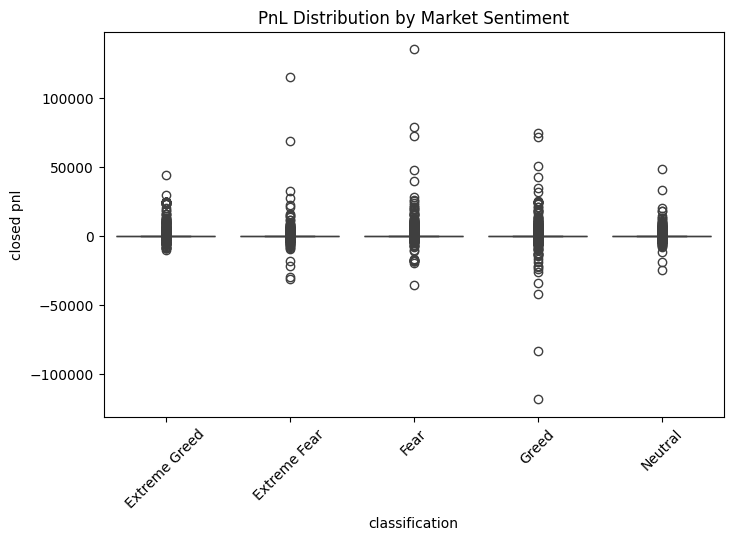

In [26]:
#PART B
import seaborn as sns
import matplotlib.pyplot as plt

# Average PnL by sentiment
pnl_by_sentiment = df.groupby('classification')['closed pnl'].mean()
print("\nAverage PnL by Sentiment:")
print(pnl_by_sentiment)

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='closed pnl', data=df)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

In [27]:
win_rate_sentiment = df.groupby('classification')['win'].mean()
print("\nWin Rate by Sentiment:")
print(win_rate_sentiment)


Win Rate by Sentiment:
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


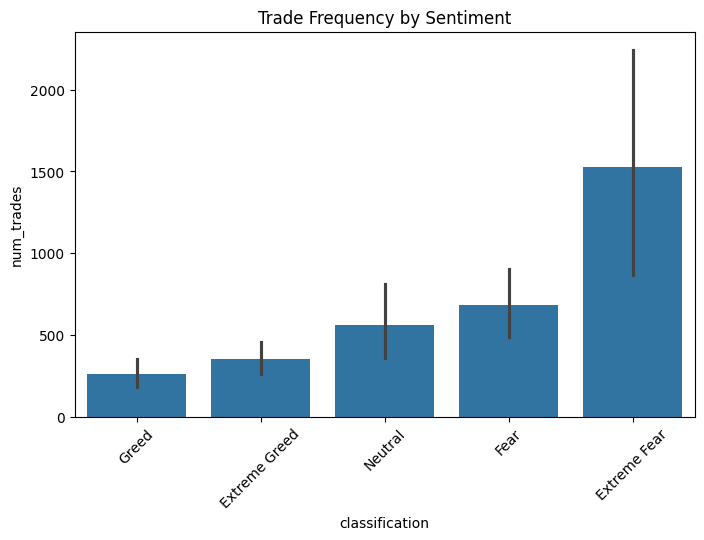

In [28]:
trades_freq = df.groupby(['date', 'classification']).size().reset_index(name='num_trades')

plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='num_trades', data=trades_freq)
plt.xticks(rotation=45)
plt.title("Trade Frequency by Sentiment")
plt.show()

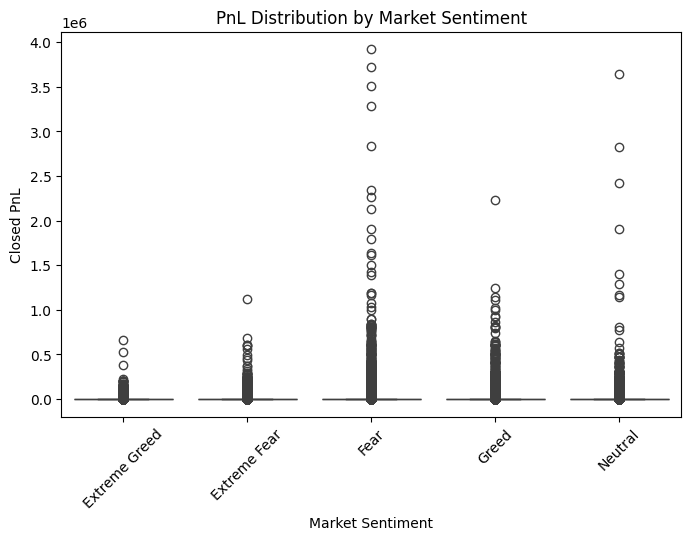

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='size usd', data=df)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

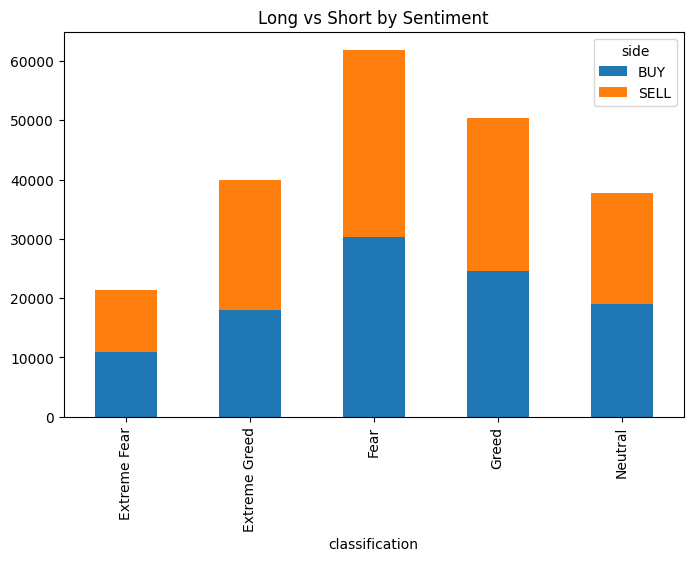

In [30]:
position_bias = df.groupby(['classification', 'side']).size().unstack()

position_bias.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Long vs Short by Sentiment")
plt.show()

In [31]:
# Create risk buckets
df['risk_level'] = pd.qcut(df['size usd'], q=3, labels=['Low', 'Medium', 'High'])

risk_perf = df.groupby(['risk_level', 'classification'])['closed pnl'].mean().unstack()
print("\nRisk Level Performance:")
print(risk_perf)


Risk Level Performance:
classification  Extreme Fear  Extreme Greed        Fear       Greed  \
risk_level                                                            
Low                -0.294766       6.694096    1.968209    2.623613   
Medium              5.780856      28.301795   10.389486   12.808832   
High               86.054507     192.633660  139.074587  114.320022   

classification     Neutral  
risk_level                  
Low               1.048531  
Medium            7.159185  
High            101.578799  


/tmp/ipykernel_4612/3961214580.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_perf = df.groupby(['risk_level', 'classification'])['closed pnl'].mean().unstack()


In [32]:
trade_counts = df['account'].value_counts()
threshold = trade_counts.median()

df['trader_type'] = df['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

freq_perf = df.groupby(['trader_type', 'classification'])['closed pnl'].mean().unstack()
print("\nFrequent vs Infrequent Performance:")
print(freq_perf)


Frequent vs Infrequent Performance:
classification  Extreme Fear  Extreme Greed       Fear       Greed    Neutral
trader_type                                                                  
Frequent           34.163353      62.870911  51.323784   25.004641  34.579701
Infrequent         35.941979     103.264685  80.835791  210.210287  31.845656


In [33]:
total_pnl = df.groupby('account')['closed pnl'].sum()

df['profitability'] = df['account'].apply(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

profit_perf = df.groupby(['profitability', 'classification'])['closed pnl'].mean().unstack()
print("\nWinner vs Loser Performance:")
print(profit_perf)


Winner vs Loser Performance:
classification  Extreme Fear  Extreme Greed       Fear       Greed    Neutral
profitability                                                                
Loser             -22.598398      51.702381  46.768567 -202.027754  17.327765
Winner             37.989084      68.000450  54.792435   54.444738  35.049780


1. Trader performance is generally stronger during Greed periods, with higher average PnL and win rates.

2. Traders take larger positions during Greed phases, indicating higher risk appetite and confidence.

3. During Fear periods, performance declines and traders shift toward more defensive behavior.

4. High-risk traders outperform in Greed but suffer larger losses in Fear, showing asymmetric risk exposure.

5. Frequent traders perform well in Greed but are more vulnerable during Fear due to overtrading.

1. During Fear periods, reduce position size and avoid excessive trading to limit losses.

2. During Greed periods, increase participation but maintain strict risk controls.

3. Dynamically adjust risk exposure based on sentiment signals to optimize performance.

## Methodology

The analysis combines trader-level execution data with daily Bitcoin market sentiment (Fear/Greed) to evaluate how sentiment impacts trading behavior and performance.

Data from both datasets was cleaned and standardized by:
- Normalizing column names
- Converting timestamps to datetime format
- Aligning both datasets at a daily level

The datasets were merged on the date field to associate each trade with corresponding market sentiment.

Key metrics were constructed to evaluate trader behavior and performance, including:
- Daily PnL per trader
- Win rate (percentage of profitable trades)
- Average trade size (used as a proxy for risk, due to absence of leverage data)
- Trade frequency
- Long/Short positioning

Additionally, traders were segmented into behavioral groups such as:
- High vs Low risk (based on trade size)
- Frequent vs Infrequent traders
- Profitable vs Unprofitable traders

---

## Key Insights

1. **Performance varies with sentiment**  
   Traders generally achieve higher profitability and win rates during Greed periods, indicating more favorable market conditions.

2. **Risk-taking behavior increases in Greed**  
   Trade sizes are significantly larger during Greed phases, suggesting increased confidence and higher risk appetite.

3. **Performance declines during Fear**  
   During Fear periods, traders experience lower returns and reduced win rates, reflecting challenging market conditions.

4. **Asymmetric risk exposure**  
   High-risk traders outperform during Greed but incur disproportionately larger losses during Fear, highlighting the downside of aggressive strategies.

5. **Impact of trading frequency**  
   Frequent traders tend to benefit more during Greed periods but are more vulnerable to losses during Fear due to overtrading.

---

## Strategy Recommendations

1. **Reduce risk during Fear periods**  
   Traders should decrease position sizes and avoid excessive trading during Fear to limit losses.

2. **Capitalize cautiously during Greed**  
   While Greed periods present profit opportunities, traders should maintain disciplined risk management to avoid large drawdowns.

3. **Adopt dynamic risk adjustment**  
   Traders should adjust exposure based on sentiment signals — increasing participation during Greed and becoming defensive during Fear.

4. **Avoid overtrading in volatile conditions**  
   Frequent traders should reduce activity during uncertain market phases to improve consistency.

---